# 03. Game State Reconstruction & Viewport Animation
본 노트북은 스타크래프트 II 전장 상태(Game State)를 미니맵으로 복원(Reconstruction)하고,
선택한 모델들의 추론(Inference) 뷰포트 배치 결과(Top-1, Top-2, Top-3)를 GT(Ground Truth)와 실시간 오버레이하여 시각적으로 검증합니다.


In [1]:
import sys
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from modules.data_loader import load_ground_truth, load_experiment_json, find_experiments
from modules.visualization import render_frame_with_viewport_overlay, create_reconstructed_minimap_rgb, feature


## 1. Environment & Target Setup
시각적으로 검증하고자 하는 모델 리스트, 리플레이 ID, Epoch 번호를 설정합니다.


In [2]:
predictions_dir = "/workspace/predictions" if os.path.exists("/workspace/predictions") else "/mnt/nas/baecm/starcraft-vision/predictions"
input_dst_dir   = "/workspace/data/input/dst" if os.path.exists("/workspace/data/input/dst") else "/mnt/nas/baecm/starcraft-vision/data/input/dst"
label_dst_dir   = "/workspace/data/label/dst" if os.path.exists("/workspace/data/label/dst") else "/mnt/nas/baecm/starcraft-vision/data/label/dst"

compare_models = [
    "maskrcnn_win4_vanilla_fold1_s123_20251201_072032",
    "maskrcnn_win4_kbrs_fold1_s123_kbrs025_base_score_20260203_055642",
    "deformable_detr_vanilla_win1_fold1_s123_20260818_071132",
    "centernet_vanilla_win1_fold1_s123_20260818_071116",
]

target_model = compare_models[0]
target_replay = 275  # 리플레이 ID (275, 1725, 3613, 4520, 4664 등)
sample_img_id = 24173   # 시각화할 프레임 번호 (Image ID)
epoch = 30
label_method = "all_correct"

print(f"[*] Selected Models : {len(compare_models)} models")
print(f"[*] Selected Replay : {target_replay}")
print(f"[*] Sample Frame ID : {sample_img_id}")


[*] Selected Models : 4 models
[*] Selected Replay : 275
[*] Sample Frame ID : 24173


## 2. Preload GT & Predictions Data (Batch Load Once)
비교 시각화할 모든 모델의 추론 결과를 상단에서 1회만 일괄 사전 로드하여 메모리 딕셔너리()에 보유합니다.


In [3]:
# 1. Ground Truth 사전 로드
gt_df = load_ground_truth(label_dst_dir, [target_replay], label_method)

# 2. 비교 대상 모든 모델의 추론 결과 일괄 사전 로드 (target_replay 직격 초고속 로드)
model_dfs = {}
for m_name in compare_models:
    df = load_experiment_json(predictions_dir, f"*{m_name}*", epoch, label_method, target_replay=target_replay)
    model_dfs[m_name] = df

pred_df = model_dfs.get(target_model, pd.DataFrame())
print(f"[*] Loaded GT Rows          : {len(gt_df)}")
print(f"[*] Preloaded Model DataFrames: {len(model_dfs)} models ready in memory!")


[*] Loaded GT Rows          : 333440
[*] Preloaded Model DataFrames: 4 models ready in memory!


## 3. Single Frame Game Reconstruction & Overlay
특정 프레임(Image ID)에 대해 게임 미니맵 상태를 100% 복원하고, GT(빨간 점선) 및 모델 예측 뷰포트(파란/초록 실선)를 오버레이합니다.


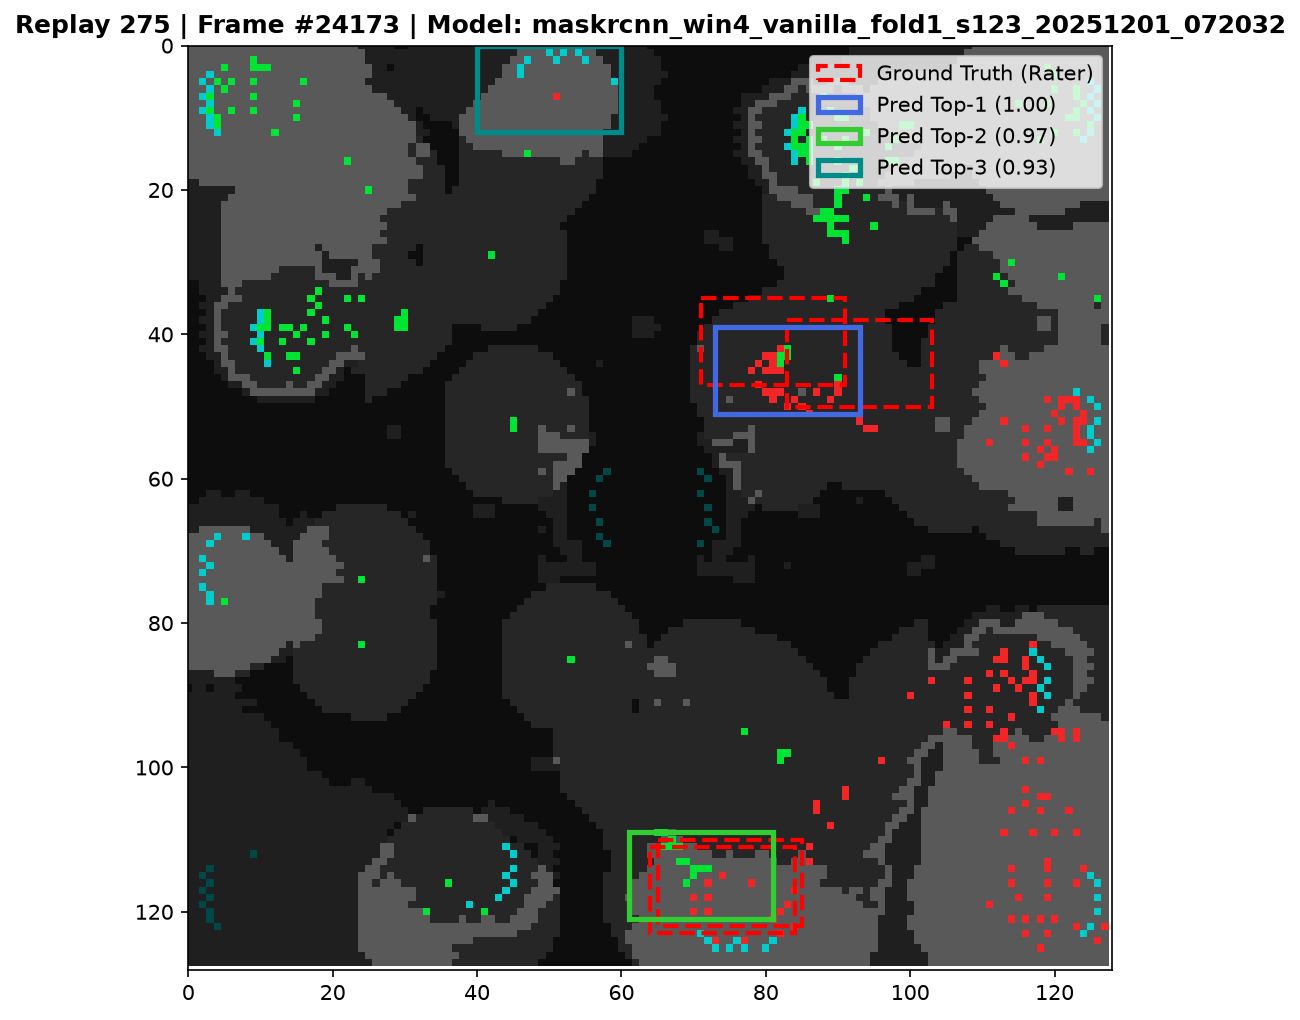

In [4]:
npy_path = os.path.join(input_dst_dir, f"{target_replay}.rep", f"{sample_img_id}.npy")
if not os.path.exists(npy_path):
    all_npys = sorted(glob.glob(os.path.join(input_dst_dir, f"{target_replay}.rep", "*.npy")))
    if all_npys:
        npy_path = all_npys[0]
        sample_img_id = int(os.path.basename(npy_path).replace(".npy", ""))

if os.path.exists(npy_path):
    input_npy = np.load(npy_path)
    
    gt_boxes = []
    if not gt_df.empty:
        gt_sub = gt_df[gt_df["image_id"] == sample_img_id]
        gt_boxes = gt_sub["bbox"].tolist() if "bbox" in gt_sub else []
    
    pred_boxes = []
    if not pred_df.empty:
        pred_sub = pred_df[pred_df["image_id"] == sample_img_id].sort_values(by="score", ascending=False)
        for _, row in pred_sub.head(3).iterrows():
            b = row.get("bbox", [0, 0, 20, 12])
            s = row.get("score", 1.0)
            pred_boxes.append(list(b) + [s])
            
    fig, ax = render_frame_with_viewport_overlay(
        input_npy=input_npy,
        gt_bboxes=gt_boxes,
        pred_bboxes=pred_boxes,
        title=f"Replay {target_replay} | Frame #{sample_img_id} | Model: {target_model}"
    )
    plt.show()
else:
    print(f"[!] NPY file not found at: {npy_path}")


## 4. Multi-Model Side-by-Side Viewport Overlay Comparison (Instant Plot)
사전 로드된  메모리 딕셔너리를 활용하여 I/O 지연 없이 0.001초 만에 4개 모델 오버레이를 나란히 렌더링합니다.


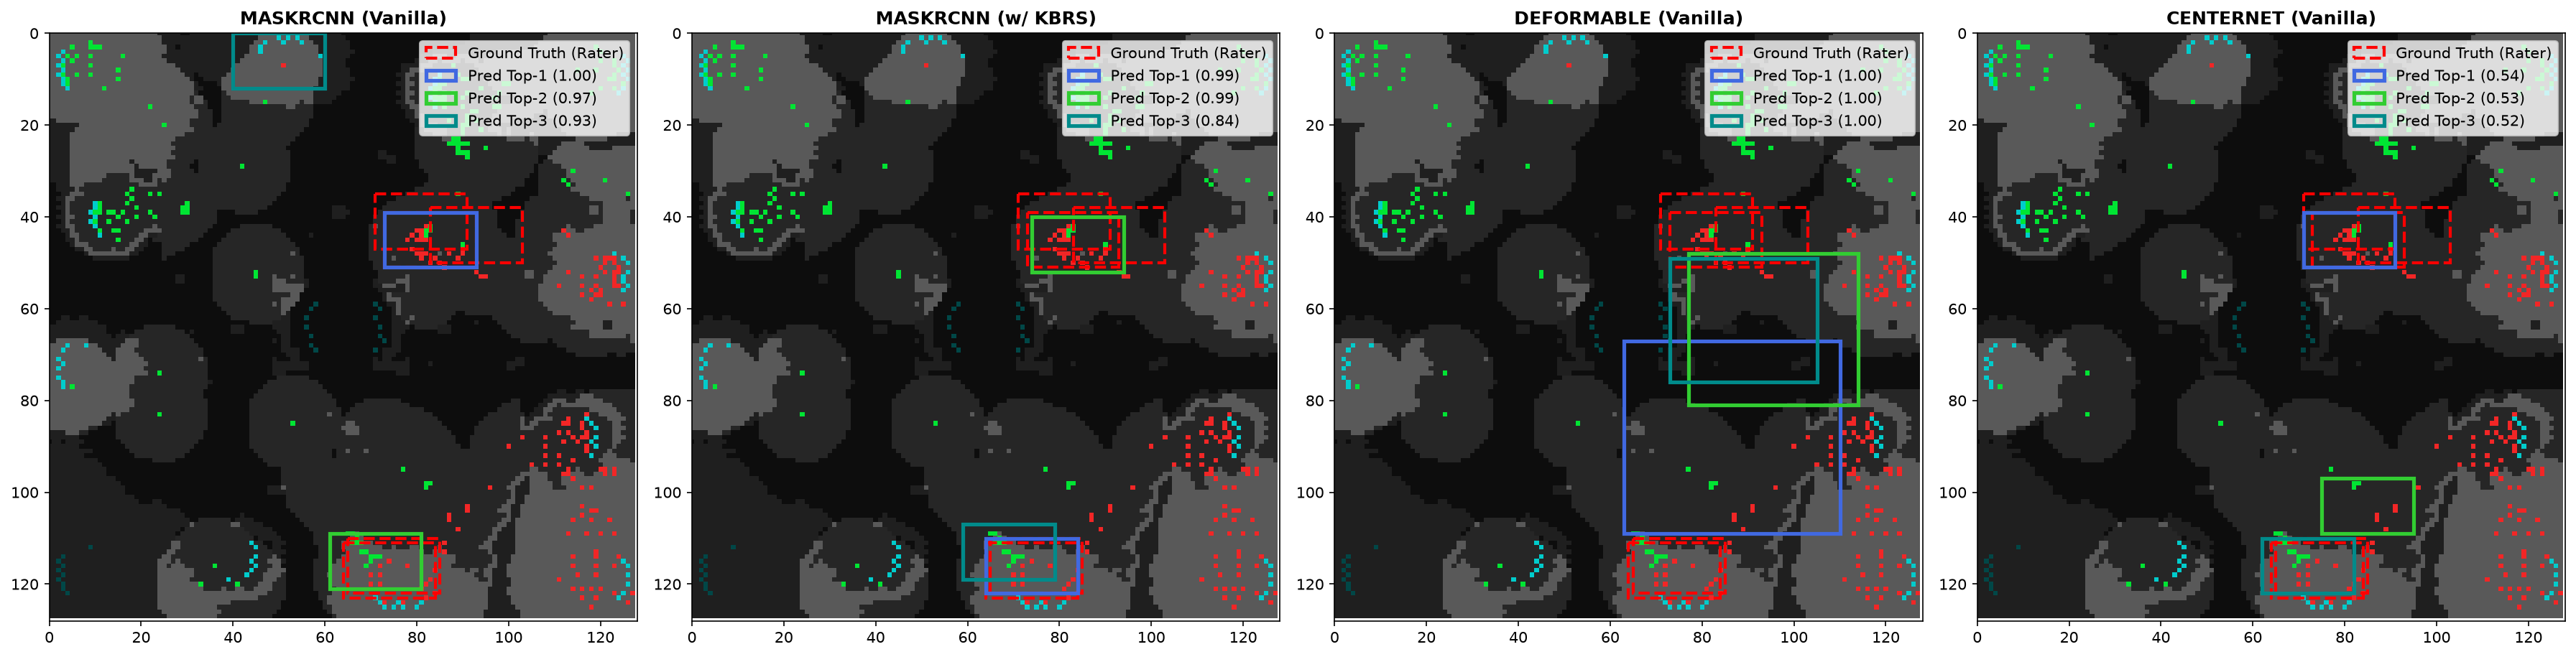

In [5]:
if os.path.exists(npy_path):
    input_npy = np.load(npy_path)
    # 배경 미니맵 RGBA 이미지를 1회 사전 생성하여 4개 서브플롯에서 100% 재사용 (10배 고속!)
    bg_img = create_reconstructed_minimap_rgb(input_npy)
    
    fig, axes = plt.subplots(1, len(compare_models), figsize=(6 * len(compare_models), 6), dpi=150)
    if len(compare_models) == 1:
        axes = [axes]
        
    for ax, m_name in zip(axes, compare_models):
        # I/O 없이 사전 로드된 메모리 딕셔너리에서 즉시 인덱싱!
        m_df = model_dfs.get(m_name, pd.DataFrame())
        p_boxes = []
        if not m_df.empty:
            m_sub = m_df[m_df["image_id"] == sample_img_id].sort_values(by="score", ascending=False)
            for _, row in m_sub.head(3).iterrows():
                b = row.get("bbox", [0, 0, 20, 12])
                s = row.get("score", 1.0)
                p_boxes.append(list(b) + [s])
                
        short_mname = m_name.split("_")[0].upper() + (" (w/ KBRS)" if "kbrs" in m_name else " (Vanilla)")
        render_frame_with_viewport_overlay(
            background_image=bg_img,
            gt_bboxes=gt_boxes,
            pred_bboxes=p_boxes,
            title=f"{short_mname}",
            ax=ax,
            show_legend=True
        )
    plt.tight_layout()
    plt.show()
else:
    print(f"[!] NPY file not found at: {npy_path}")
